In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Load datasets & Print shape

ch = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/chi2_pca_df.csv")
rf = pd.read_csv("/content/drive/MyDrive/SLIIT/AI_ML/Project/rfe_pca_df.csv")

print(f"chi2_pca_df shape: {ch.shape}")
print(f"rfe_pca_df shape: {rf.shape}")

chi2_pca_df shape: (27875, 10)
rfe_pca_df shape: (27875, 9)


In [10]:
print("Balance of 'Depression' in chi2_pca_df:")
print(ch['Depression'].value_counts())
print("\nBalance of 'Depression' in rfe_pca_df:")
print(rf['Depression'].value_counts())

Balance of 'Depression' in chi2_pca_df:
Depression
1    16321
0    11554
Name: count, dtype: int64

Balance of 'Depression' in rfe_pca_df:
Depression
1    16321
0    11554
Name: count, dtype: int64


In [11]:
# Prepare data for chi2_pca_df dataset
X_ch = ch.drop('Depression', axis=1)
y_ch = ch['Depression']

# Train-test split for chi2_pca_df
X_train_ch, X_test_ch, y_train_ch, y_test_ch = train_test_split(
    X_ch, y_ch, test_size=0.2, random_state=42)

print("\nchi2_pca_df Dataset Info:")
print(f"Training set: {X_train_ch.shape[0]} samples") # Get rows count
print(f"Test set: {X_test_ch.shape[0]} samples")
print(f"Feature dimension: {X_train_ch.shape[1]}")   # Get column count


chi2_pca_df Dataset Info:
Training set: 22300 samples
Test set: 5575 samples
Feature dimension: 9


In [12]:
# Prepare data for rfe_pca_df dataset
X_rf = rf.drop('Depression', axis=1)
y_rf = rf['Depression']

# Train-test split for rfe_pca_df
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42)

print("\nrfe_pca_df Dataset Info:")
print(f"Training set: {X_train_rf.shape[0]} samples")
print(f"Test set: {X_test_rf.shape[0]} samples")
print(f"Feature dimension: {X_train_rf.shape[1]}")


rfe_pca_df Dataset Info:
Training set: 22300 samples
Test set: 5575 samples
Feature dimension: 8


In [13]:
# BASELINE MODEL - DEFAULT PARAMETERS
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

    # Detailed classification report
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

    return y_pred

In [14]:
# Baseline model for chi2_pca_df
print("\n--- chi2_pca_df Baseline Model ---")
knn_baseline_ch = KNeighborsClassifier()
knn_baseline_ch.fit(X_train_ch, y_train_ch)
y_pred_baseline_ch = evaluate_model(knn_baseline_ch, X_test_ch, y_test_ch, "Baseline KNN")


--- chi2_pca_df Baseline Model ---

Baseline KNN Performance:
Accuracy: 0.8167
Precision: 0.8327
Recall: 0.8583
F1-Score: 0.8453

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78      2322
           1       0.83      0.86      0.85      3253

    accuracy                           0.82      5575
   macro avg       0.81      0.81      0.81      5575
weighted avg       0.82      0.82      0.82      5575



In [15]:
# Baseline model for rfe_pca_df
print("\n--- rfe_pca_df Baseline Model ---")
knn_baseline_rf = KNeighborsClassifier()
knn_baseline_rf.fit(X_train_rf, y_train_rf)
y_pred_baseline_rf = evaluate_model(knn_baseline_rf, X_test_rf, y_test_rf, "Baseline KNN")


--- rfe_pca_df Baseline Model ---

Baseline KNN Performance:
Accuracy: 0.8231
Precision: 0.8357
Recall: 0.8675
F1-Score: 0.8513

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78      2322
           1       0.84      0.87      0.85      3253

    accuracy                           0.82      5575
   macro avg       0.82      0.81      0.82      5575
weighted avg       0.82      0.82      0.82      5575



In [16]:
# HYPERPARAMETER TUNING WITH GRIDSEARCHCV

# Define parameter grid for systematic tuning
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

def perform_grid_search(X_train, y_train, X_test, y_test, dataset_name):
    print(f"\n--- Grid Search for {dataset_name} ---")

    # Create KNN classifier
    knn = KNeighborsClassifier()

    # Perform GridSearchCV with 5-fold cross-validation
    grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy',
        n_jobs=-1, verbose=1
    )

    print("Performing GridSearchCV...")
    grid_search.fit(X_train, y_train)

    # Best parameters and score
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")

    # Evaluate best model
    best_knn = grid_search.best_estimator_
    y_pred = best_knn.predict(X_test)

    print(f"\nTest Set Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred))

    return grid_search, best_knn

In [17]:
# Perform grid search for chi2_pca_df dataset
grid_search_ch, best_knn_ch = perform_grid_search(
    X_train_ch, y_train_ch, X_test_ch, y_test_ch, "chi2_pca_df"
)


--- Grid Search for chi2_pca_df ---
Performing GridSearchCV...
Fitting 5 folds for each of 42 candidates, totalling 210 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best Cross-validation Score: 0.8371

Test Set Performance:
Accuracy: 0.8303
Precision: 0.8380
Recall: 0.8792
F1-Score: 0.8581

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79      2322
           1       0.84      0.88      0.86      3253

    accuracy                           0.83      5575
   macro avg       0.83      0.82      0.82      5575
weighted avg       0.83      0.83      0.83      5575



In [18]:
# Perform grid search for rfe_pca_df dataset
grid_search_rf, best_knn_rf = perform_grid_search(
    X_train_rf, y_train_rf, X_test_rf, y_test_rf, "rfe_pca_df"
)


--- Grid Search for rfe_pca_df ---
Performing GridSearchCV...
Fitting 5 folds for each of 42 candidates, totalling 210 fits

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
Best Cross-validation Score: 0.8395

Test Set Performance:
Accuracy: 0.8418
Precision: 0.8492
Recall: 0.8863
F1-Score: 0.8673

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80      2322
           1       0.85      0.89      0.87      3253

    accuracy                           0.84      5575
   macro avg       0.84      0.83      0.84      5575
weighted avg       0.84      0.84      0.84      5575



In [19]:
# MANUAL K-VALUE EXPLORATION (CREATING MODEL VARIETIES)
def explore_k_values(X_train, y_train, X_test, y_test, dataset_name, k_range=range(1, 41)):
    print(f"\n--- K-value Exploration for {dataset_name} ---")

    train_scores = []
    test_scores = []

    for k in k_range:
        # Create KNN with different k values
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)

        # Calculate scores
        train_score = knn.score(X_train, y_train)
        test_score = knn.score(X_test, y_test)

        train_scores.append(train_score)
        test_scores.append(test_score)

    # Find best k
    best_k_index = np.argmax(test_scores)
    best_k = k_range[best_k_index]
    best_accuracy = test_scores[best_k_index]

    print(f"Best k value: {best_k} with accuracy: {best_accuracy:.4f}")

    # Train final model with best k
    best_knn = KNeighborsClassifier(n_neighbors=best_k)
    best_knn.fit(X_train, y_train)
    y_pred_best = best_knn.predict(X_test)

    print(f"Final Model Performance with k={best_k}:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred_best):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred_best):.4f}")
    print("\nDetailed Classification Report:") # Added classification report
    print(classification_report(y_test, y_pred_best)) # Corrected y_pred to y_pred_best

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(k_range, train_scores, label='Training Accuracy', marker='o')
    plt.plot(k_range, test_scores, label='Test Accuracy', marker='s')
    plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
    plt.xlabel('k Value')
    plt.ylabel('Accuracy')
    plt.title(f'KNN Accuracy vs k Value - {dataset_name}')
    plt.legend()
    plt.grid(True)
    plt.xticks(range(1, 41, 2))
    plt.show()

    return best_knn, best_k, best_accuracy, train_scores, test_scores


--- K-value Exploration for chi2_pca_df ---
Best k value: 24 with accuracy: 0.8357
Final Model Performance with k=24:
Accuracy: 0.8357
Precision: 0.8464
Recall: 0.8777
F1-Score: 0.8618

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      2322
           1       0.85      0.88      0.86      3253

    accuracy                           0.84      5575
   macro avg       0.83      0.83      0.83      5575
weighted avg       0.84      0.84      0.84      5575



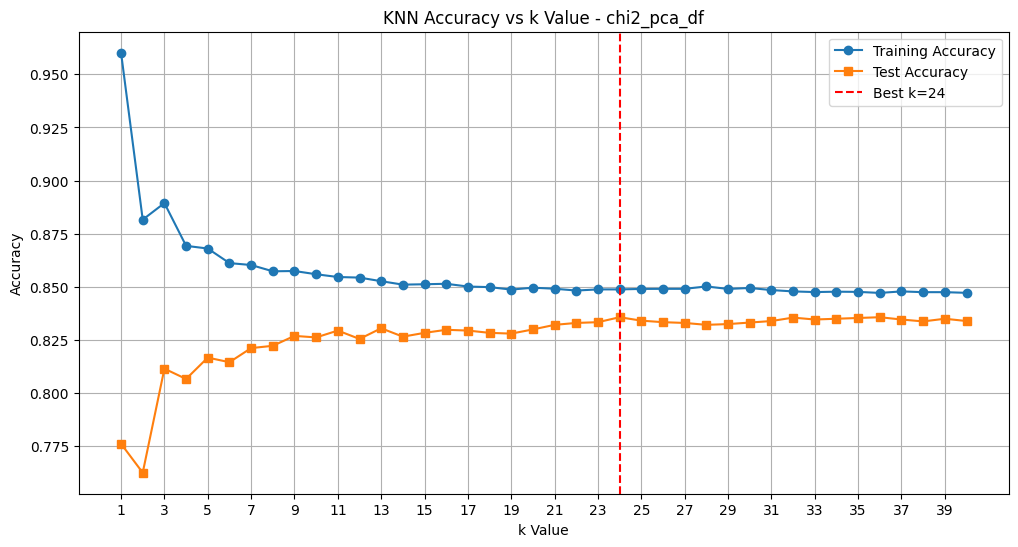

In [20]:
# Explore k-values for chi2_pca_df dataset
best_knn_ch_k, best_k_ch, best_acc_ch, train_scores_ch, test_scores_ch = explore_k_values(
    X_train_ch, y_train_ch, X_test_ch, y_test_ch, "chi2_pca_df"
)


--- K-value Exploration for rfe_pca_df ---
Best k value: 36 with accuracy: 0.8430
Final Model Performance with k=36:
Accuracy: 0.8430
Precision: 0.8512
Recall: 0.8860
F1-Score: 0.8682

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.81      2322
           1       0.85      0.89      0.87      3253

    accuracy                           0.84      5575
   macro avg       0.84      0.83      0.84      5575
weighted avg       0.84      0.84      0.84      5575



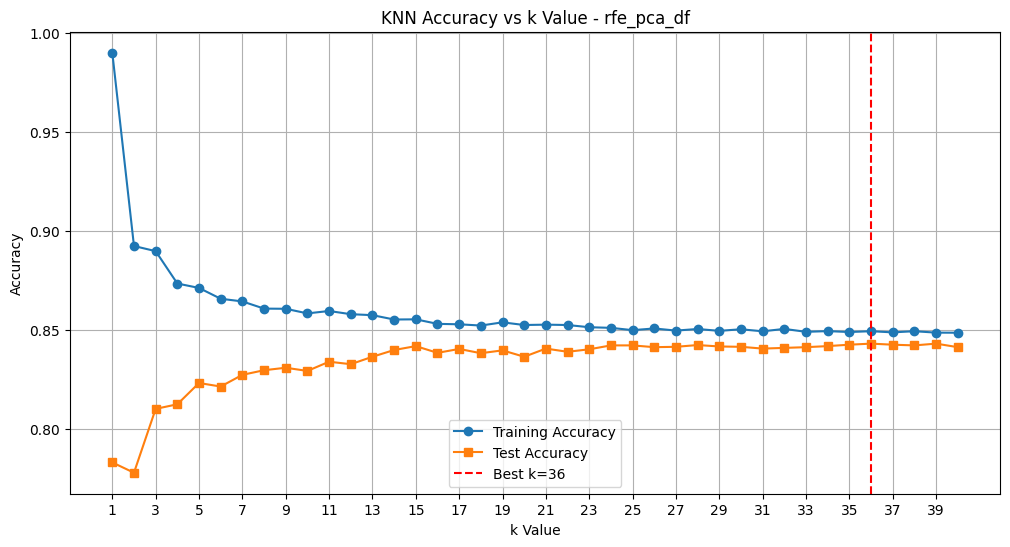

In [21]:
# Explore k-values for rfe_pca_df dataset
best_knn_rf_k, best_k_rf, best_acc_rf, train_scores_rf, test_scores_rf = explore_k_values(
    X_train_rf, y_train_rf, X_test_rf, y_test_rf, "rfe_pca_df"
)

Best Model: KNN with k=36 on rfe_pca_df
Best Accuracy: 0.8430

Detailed Performance Metrics:
Accuracy: 0.8430
Precision: 0.8512
Recall: 0.8860
F1-Score: 0.8682

Confusion Matrix:
[[1818  504]
 [ 371 2882]]


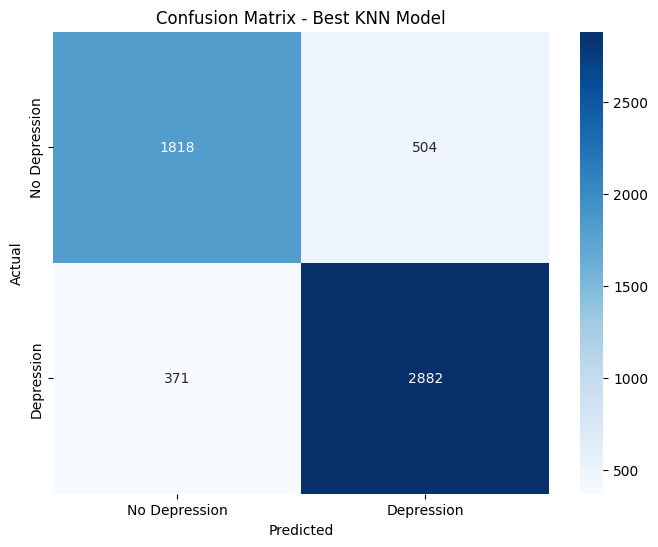


Detailed Classification Report:
               precision    recall  f1-score   support

No Depression       0.83      0.78      0.81      2322
   Depression       0.85      0.89      0.87      3253

     accuracy                           0.84      5575
    macro avg       0.84      0.83      0.84      5575
 weighted avg       0.84      0.84      0.84      5575



In [22]:
# DETAILED EVALUATION OF BEST MODEL

# Identify best model
best_model = best_knn_rf_k  # From manual k exploration on rfe_pca_df
best_dataset = "rfe_pca_df"
X_test_best = X_test_rf
y_test_best = y_test_rf

print(f"Best Model: KNN with k={best_k_rf} on {best_dataset}")
print(f"Best Accuracy: {best_acc_rf:.4f}")

# Comprehensive evaluation
y_pred_best = best_model.predict(X_test_best)

print("\nDetailed Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test_best, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test_best, y_pred_best):.4f}")
print(f"Recall: {recall_score(y_test_best, y_pred_best):.4f}")
print(f"F1-Score: {f1_score(y_test_best, y_pred_best):.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_best, y_pred_best)
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Depression', 'Depression'],
            yticklabels=['No Depression', 'Depression'])
plt.title('Confusion Matrix - Best KNN Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test_best, y_pred_best,
                          target_names=['No Depression', 'Depression']))

In [23]:
# CROSS-VALIDATION

# Perform 5-fold cross-validation on best model
cv_scores = cross_val_score(best_model, X_train_rf, y_train_rf, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

5-Fold Cross-Validation Results:
Cross-validation scores: [0.83811659 0.84103139 0.83946188 0.85067265 0.8426009 ]
Mean CV Accuracy: 0.8424 (+/- 0.0088)


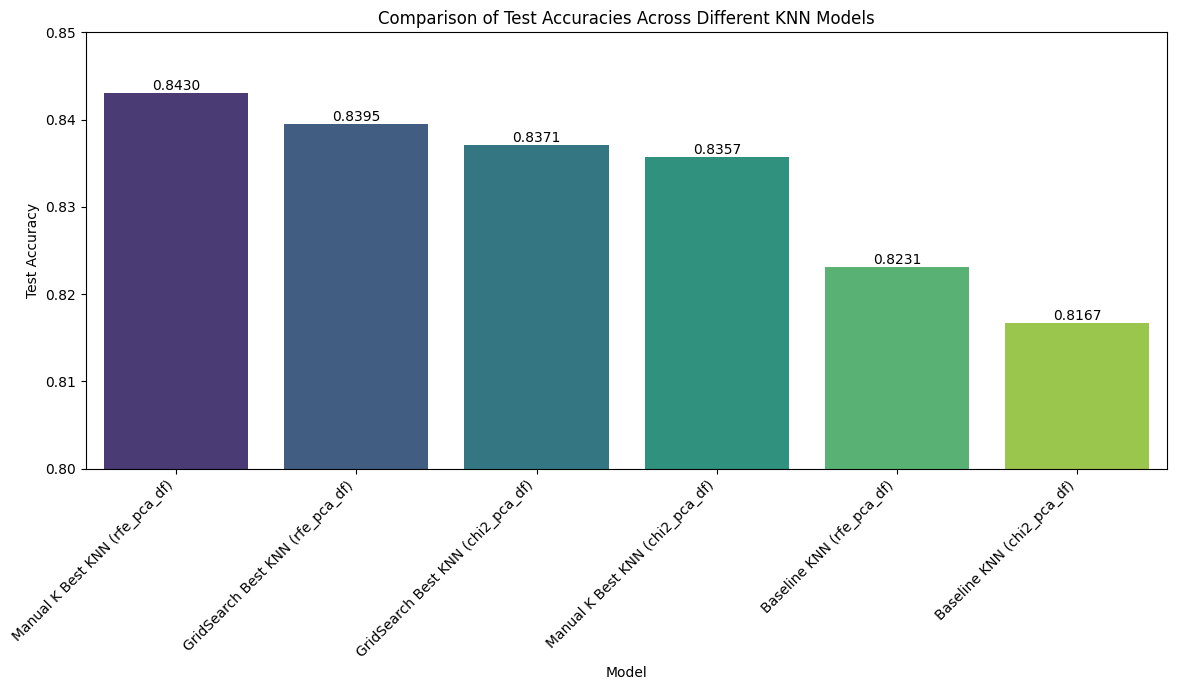

In [24]:
# Collect accuracy scores from the different models
model_accuracies = {
    "Baseline KNN (chi2_pca_df)": accuracy_score(y_test_ch, y_pred_baseline_ch),
    "Baseline KNN (rfe_pca_df)": accuracy_score(y_test_rf, y_pred_baseline_rf),
    "GridSearch Best KNN (chi2_pca_df)": grid_search_ch.best_score_, # Using best cross-validation score
    "GridSearch Best KNN (rfe_pca_df)": grid_search_rf.best_score_, # Using best cross-validation score
    "Manual K Best KNN (chi2_pca_df)": best_acc_ch,
    "Manual K Best KNN (rfe_pca_df)": best_acc_rf
}

# Create a pandas Series for easy plotting
accuracy_series = pd.Series(model_accuracies)

# Sort the accuracies for better visualization
accuracy_series = accuracy_series.sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=accuracy_series.index, y=accuracy_series.values, palette='viridis')
plt.title('Comparison of Test Accuracies Across Different KNN Models')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.ylim(0.8, 0.85) # Set y-axis limits to highlight differences
plt.tight_layout()

# Add accuracy values on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()